
Import Libraries

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

upload dataset

In [21]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


Load Dataset

In [22]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Dataset Information

In [23]:
print(df.shape)

df.info()

df.describe()

(9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dt

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


Check Missing Values

In [24]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Convert Dates

In [26]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

Feature Engineering

In [27]:
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Day"] = df["Order Date"].dt.day

df["Ship_Year"] = df["Ship Date"].dt.year
df["Ship_Month"] = df["Ship Date"].dt.month
df["Ship_Day"] = df["Ship Date"].dt.day

Drop Unnecessary Columns

In [28]:
drop_columns = [

"Row ID",
"Order ID",
"Order Date",
"Ship Date",
"Customer ID",
"Customer Name",
"Postal Code",
"Product ID",
"Product Name"

]

df = df.drop(columns=drop_columns)

Separate Features and Target

In [29]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

Identify Categorical and Numerical Columns

In [30]:
categorical_cols = X.select_dtypes(include=["object"]).columns

numerical_cols = X.select_dtypes(exclude=["object"]).columns

print(categorical_cols)

print(numerical_cols)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
       'Category', 'Sub-Category'],
      dtype='object')
Index(['Order_Year', 'Order_Month', 'Order_Day', 'Ship_Year', 'Ship_Month',
       'Ship_Day'],
      dtype='object')


preprocessing Pipeline

In [31]:
numeric_transformer = Pipeline(

steps=[
("imputer", SimpleImputer(strategy="median"))
]

)

categorical_transformer = Pipeline(

steps=[
("imputer", SimpleImputer(strategy="most_frequent")),
("onehot", OneHotEncoder(handle_unknown="ignore"))
]

)

preprocessor = ColumnTransformer(

transformers=[

("num", numeric_transformer, numerical_cols),

("cat", categorical_transformer, categorical_cols)

]

)

Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
X,y,
test_size=0.2,
random_state=42
)

Linear Regression

In [33]:
lr_model = Pipeline(

steps=[

("preprocessor", preprocessor),

("model", LinearRegression())

]

)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

Decision Tree

In [34]:
dt_model = Pipeline(

steps=[

("preprocessor", preprocessor),

("model", DecisionTreeRegressor(random_state=42))

]

)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

Random Forest

In [37]:
rf_model = Pipeline(

steps=[

("preprocessor", preprocessor),

("model", RandomForestRegressor(

n_estimators=200,

random_state=42

))

]

)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Evaluation Function

In [39]:
def evaluate(name,y_true,y_pred):

    print("="*50)

    print(name)

    print("="*50)

    print("MAE :",mean_absolute_error(y_true,y_pred))

    print("RMSE :",np.sqrt(mean_squared_error(y_true,y_pred)))

    print("R2 Score :",r2_score(y_true,y_pred))

    print()

Evaluate Models

In [40]:
evaluate("Linear Regression",y_test,lr_pred)

evaluate("Decision Tree",y_test,dt_pred)

evaluate("Random Forest",y_test,rf_pred)

Linear Regression
MAE : 258.9106889666103
RMSE : 746.8210400888095
R2 Score : 0.16555680542332418

Decision Tree
MAE : 292.5658071938775
RMSE : 902.1842832397248
R2 Score : -0.21773896200826637

Random Forest
MAE : 253.0597863920426
RMSE : 801.8072685353706
R2 Score : 0.038158159104566436



Actual vs Predicted

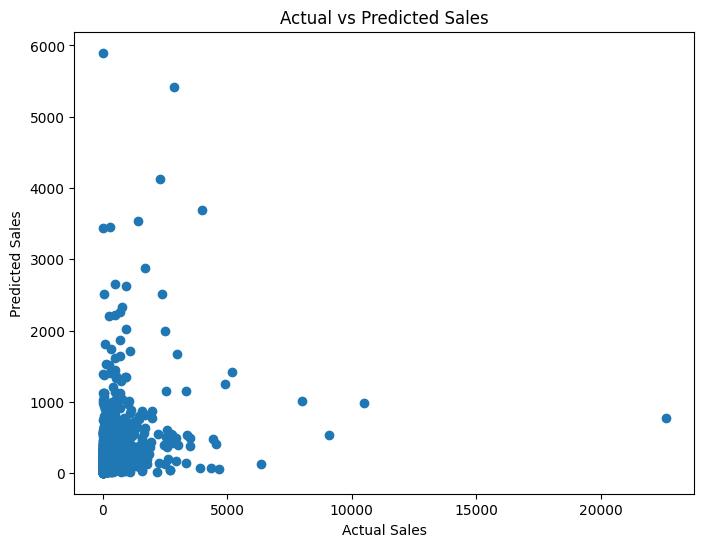

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,rf_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

Compare models


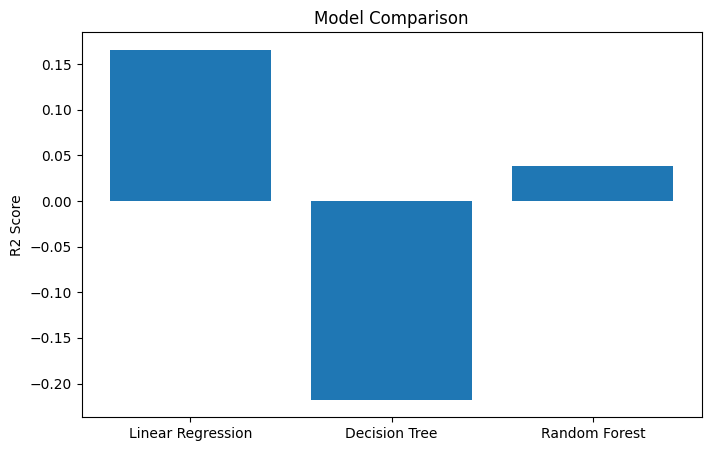

In [44]:
models = ["Linear Regression","Decision Tree","Random Forest"]

scores = [

r2_score(y_test,lr_pred),

r2_score(y_test,dt_pred),

r2_score(y_test,rf_pred)

]

plt.figure(figsize=(8,5))

plt.bar(models,scores)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

Predict New Data

In [51]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

pred = rf_model.predict(X_test)

print("Prediction successful!")

Prediction successful!


Save model


In [52]:
import joblib

joblib.dump(rf_model,"smart_retail_sales_model.pkl")

print("Model saved successfully!")

Model saved successfully!
